# Community Detection: Multi-Community QUBO + QIGNN ($k > 2$)

Расширение `community_detection_k2_karate.ipynb` на $k > 2$ сообществ через
формулу (5) из Wang et al. 2024 (*Quantum Computing in Community Detection
for Anti-Fraud Applications*, Entropy):

$$
\min_{X\in\{0,1\}^{n\times k}}\;\;
-\frac{1}{2m}\sum_{c=1}^{k}\sum_{v,w} B_{vw}\, x_{v,c}x_{w,c}
\;+\; P\sum_v \Bigl(\sum_c x_{v,c} - 1\Bigr)^2
$$

Линеаризация $i = v\cdot k + c$ → задача QUBO размера $N = n\cdot k$.
QUBO-словарь строится в `qubo_modularity.gen_q_dict_modularity_multi`.

GNN-солвер:

* `ResSAGEMulti` — копия `ResSAGE` с softmax-выходом по dim=1 (распределение
  по $k$ сообществам на вершину) вместо sigmoid;
* `loss_func_multi(P, Q)` — `p_flat = P.reshape(-1)`, $\mathcal L = p^\top Q p +$ annealing penalty;
* в постобработке — `argmax` по dim=1, целочисленные метки $0..k-1$.

Эксперимент: Zachary's karate, $k\in\{2,3,4,5,6\}$, 5 shots на каждое $k$, лучший
по модулярности. Сравнение с Louvain.

In [1]:
import dgl
import torch
import random
import os
import sys
import numpy as np
import networkx as nx
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from collections import OrderedDict, defaultdict
from dgl.nn.pytorch import SAGEConv
from itertools import chain, islice
from time import time

from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

# Local module with QUBO-modularity formulations.
sys.path.insert(0, os.getcwd())
from qubo_modularity import (
    gen_q_dict_modularity_multi,
    gen_q_dict_modularity_2community,
    linearize_index,
    delinearize_index,
)

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

%matplotlib inline

/opt/homebrew/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

TORCH_DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TORCH_DTYPE = torch.float32
print(f'Device: {TORCH_DEVICE}, dtype: {TORCH_DTYPE}')

Device: cpu, dtype: torch.float32


# Step 1 — Архитектура GNN для multi-class

In [3]:
class SAGEResBlockMulti(torch.nn.Module):
    """Same SAGEResBlock as in the k=2 notebook, kept self-contained here."""
    def __init__(self, in_channels, out_channels, feat_drop=0.):
        super().__init__()
        self.sage1 = SAGEConv(in_channels, out_channels, aggregator_type='mean',
                              feat_drop=feat_drop, bias=False)
        # bn1 sees sage1's output (out_channels) -- patch retained.
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.sage2 = SAGEConv(in_channels, out_channels, aggregator_type='pool',
                              feat_drop=feat_drop, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu = nn.LeakyReLU()

    def forward(self, graph, x, edge_weight=None):
        out1 = self.bn1(self.sage1(graph, x, edge_weight))
        out2 = self.bn2(self.sage2(graph, x, edge_weight))
        return self.relu(out1 + out2)


class ResSAGEMulti(torch.nn.Module):
    """Multi-community variant of ResSAGE.

    Differences from ResSAGE:
      * final activation is **softmax along community dim** (instead of sigmoid),
        so output is a per-node distribution over k communities.
      * h0 (recurrent input) has shape (n, k) instead of (n, 1).
    """
    def __init__(self, in_feats, hidden_sizes, number_classes, dropout, device):
        super().__init__()
        self.dropout_frac = dropout
        self.number_classes = number_classes
        self.layers = nn.ModuleList()
        current_dim = in_feats

        if isinstance(hidden_sizes, int):
            hidden_sizes = [hidden_sizes]

        for hdim in hidden_sizes:
            self.layers.append(SAGEResBlockMulti(current_dim, hdim).to(device))
            self.layers.append(torch.nn.LeakyReLU())
            current_dim = hdim

        self.layers.append(SAGEConv(current_dim, number_classes,
                                    aggregator_type='mean').to(device))

    def forward(self, graph, h, h0, edge_weight=None):
        h = torch.cat([h, h0], 1)
        for layer, norm in zip(self.layers[:-1][::2], self.layers[:-1][1::2]):
            h = layer(graph, h, edge_weight)
            h = norm(h)
        h = F.dropout(h, p=self.dropout_frac)
        h0_new = self.layers[-1](graph, h, edge_weight)
        # softmax over community dim => per-node distribution that sums to 1.
        probs = F.softmax(h0_new, dim=1)
        return probs, h0_new


def get_gnn_multi(n_nodes, gnn_hypers, opt_params, torch_device, torch_dtype):
    dim_embedding = gnn_hypers['dim_embedding']
    hidden_dim = gnn_hypers['hidden_dim']
    dropout = gnn_hypers['dropout']
    number_classes = gnn_hypers['number_classes']

    # Same input feature dim as original ResSAGE: dim_emb + 1*k + 4*dim_emb
    # (random + ones + ones + walk_pagerank(=2*dim_emb)) + h0(=k) recurrent
    # h+h0 cat dim = 5*dim_embedding + k = 50+k for our hypers.
    in_feats = dim_embedding + 1 * number_classes + 4 * dim_embedding
    net = ResSAGEMulti(in_feats, hidden_dim, number_classes, dropout, torch_device)
    net = net.type(torch_dtype).to(torch_device)
    embed = nn.Embedding(n_nodes, dim_embedding)
    embed = embed.type(torch_dtype).to(torch_device)
    optimizer = torch.optim.Adam(chain(net.parameters(), embed.parameters()),
                                 **opt_params)
    return net, embed, optimizer

# Step 2 — Лосс для multi-class случая

In [4]:
def loss_func_multi(P, Q_mat, epoch=0):
    """
    P : torch.Tensor of shape (n, k) -- per-node community distribution (softmax).
    Q_mat : (n*k, n*k) torch matrix encoding modularity + one-hot constraint.

    Linearisation: P.reshape(-1) yields p_flat with index i = v*k + c,
    matching `linearize_index(v, c, k)`.

    Cost: p_flat.T @ Q_mat @ p_flat + (epoch/1e4) * sum_i |p_i (1 - p_i)|
    (annealing penalty pushes individual entries toward {0,1}; combined with
    softmax row-sum=1 this drives one-hot solutions).
    """
    p_flat = P.reshape(-1)
    p_col = p_flat.unsqueeze(1)
    lbd = epoch / 1e4
    penalty = (p_flat - 1) * p_flat
    cost = (p_col.T @ Q_mat @ p_col).squeeze() + lbd * penalty.abs().sum()
    return cost

# Step 3 — Тренировочный цикл для multi-class

In [5]:
def pagerank_features(nx_graph, feature_dim=10):
    features = torch.zeros((nx_graph.number_of_nodes(), feature_dim))
    pr = nx.pagerank(nx.Graph(nx_graph))
    for v, val in pr.items():
        features[v, :] = val
    return features


def _modularity_edge_weights(nx_G, dgl_graph, dtype, device):
    """Per-DGL-edge weights = -B[u,v] (matches the modularity signal used in the
    original 2-community notebook). Built from the n*n modularity matrix B (NOT
    from the n*k Q matrix, which lives in linearised (v,c) space)."""
    nodes = list(nx_G.nodes())
    A = nx.to_numpy_array(nx_G, nodelist=nodes, weight=None)
    deg = A.sum(axis=1)
    m = nx_G.number_of_edges()
    B = A - np.outer(deg, deg) / (2.0 * m)
    B_t = torch.tensor(-B, dtype=dtype, device=device)
    src, dst = dgl_graph.edges()
    return B_t[src, dst]


def run_gnn_training_multi(q_torch, dgl_graph, nx_G, k, net, embed, optimizer,
                           number_epochs, tol, patience, verbose=True):
    """Multi-class QIGNN training. Returns (net, best_epoch, best_probs,
    best_assignment, best_loss).

    Differences from run_gnn_training:
      * h0 has shape (n, k) (one logit per community), not (n, 1).
      * assignment = argmax(probs, dim=1) (integer labels), not threshold.
      * edge_weight comes from the n*n modularity matrix, since q_torch is
        n*k by n*k and indexing it by graph edges would be wrong.
    """
    n = dgl_graph.number_of_nodes()
    dtype = q_torch.dtype
    device = q_torch.device

    edge_weight = _modularity_edge_weights(nx_G, dgl_graph, dtype, device)

    inputs = torch.rand((n, 10), dtype=dtype, device=device)
    walk = pagerank_features(dgl_graph.cpu().to_networkx(), 2 * inputs.shape[1])
    inputs = torch.cat([inputs, torch.ones_like(inputs), torch.ones_like(inputs),
                        walk.to(device)], 1)

    h0 = torch.zeros(n, k, device=device, dtype=dtype)

    prev_loss = 1.0
    count = 0

    # Initial best: degenerate one-hot (all to community 0). Constraint satisfied.
    init_assn = torch.zeros(n, dtype=torch.long, device=device)
    X0 = torch.zeros(n, k, dtype=dtype, device=device)
    X0[:, 0] = 1.0
    best_loss = loss_func_multi(X0, q_torch).detach()
    best_assignment = init_assn.clone()
    best_probs = X0.clone()
    best_epoch = 0
    best_proj_loss = best_loss.clone()

    t0 = time()
    for epoch in range(number_epochs):
        probs, h0 = net(dgl_graph, inputs, h0.detach(), edge_weight)  # (n, k)

        loss = loss_func_multi(probs, q_torch, epoch)
        loss_val = loss.detach().item()

        # Project to one-hot via argmax and evaluate the *binary* cost
        with torch.no_grad():
            assignment = probs.argmax(dim=1)
            X_proj = torch.zeros_like(probs)
            X_proj.scatter_(1, assignment.unsqueeze(1), 1.0)
            proj_loss = loss_func_multi(X_proj, q_torch).detach()

            if proj_loss < best_proj_loss:
                best_proj_loss = proj_loss
                best_loss = proj_loss
                best_assignment = assignment.detach().clone()
                best_probs = probs.detach().clone()
                best_epoch = epoch

        if verbose and epoch % 1000 == 0:
            print(f'  Epoch {epoch}: loss={loss_val:.4f}, '
                  f'best proj loss={float(best_proj_loss):.4f}')

        if (abs(loss_val - prev_loss) <= tol) | ((loss_val - prev_loss) > 0):
            count += 1
        else:
            count = 0
        if count >= patience:
            if verbose:
                print(f'  early stop @ epoch {epoch} (patience={patience})')
            break
        prev_loss = loss_val

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), max_norm=2.0, norm_type=2)
        optimizer.step()

    elapsed = time() - t0
    if verbose:
        print(f'  GNN train ({n} nodes, k={k}) took {elapsed:.2f}s, '
              f'best epoch={best_epoch}, best proj loss={float(best_proj_loss):.4f}')
    return net, best_epoch, best_probs, best_assignment, best_loss

# Step 4 — Метрики для multi-class

In [6]:
def assignment_to_communities(assignment, nodes):
    """Vector of integer labels -> list of frozensets (one per non-empty class)."""
    if torch.is_tensor(assignment):
        assignment = assignment.detach().cpu().numpy()
    assignment = np.asarray(assignment).astype(int).tolist()
    groups = defaultdict(set)
    for node, label in zip(nodes, assignment):
        groups[int(label)].add(node)
    return [frozenset(s) for s in groups.values() if len(s) > 0]


def modularity_from_assignment(nx_G, assignment, nodes=None):
    if nodes is None:
        nodes = list(nx_G.nodes())
    communities = assignment_to_communities(assignment, nodes)
    if len(communities) <= 1:
        return 0.0
    return float(nx.community.modularity(nx_G, communities))


def nmi_from_assignment(true_labels, pred_assignment):
    if torch.is_tensor(pred_assignment):
        pred_assignment = pred_assignment.detach().cpu().numpy()
    return float(normalized_mutual_info_score(np.asarray(true_labels),
                                              np.asarray(pred_assignment).astype(int)))

# Step 5 — Эксперимент на karate, $k\in\{2,3,4,5,6\}$

In [7]:
graph = nx.karate_club_graph()
nodes = list(graph.nodes())
n_nodes = len(nodes)
print(f'Karate: n={n_nodes}, m={graph.number_of_edges()}')

club_to_label = {'Mr. Hi': 0, 'Officer': 1}
true_labels = np.array([club_to_label[graph.nodes[v]['club']] for v in nodes])

graph_dgl = dgl.from_networkx(graph).to(TORCH_DEVICE)

# ---- Louvain baseline (k chosen automatically) ----
t0 = time()
louv_comms = nx.community.louvain_communities(graph, seed=SEED)
louv_time = time() - t0
louv_mod = float(nx.community.modularity(graph, louv_comms))
node_to_comm = {v: cidx for cidx, c in enumerate(louv_comms) for v in c}
louv_pred = np.array([node_to_comm[v] for v in nodes])
louv_nmi = float(normalized_mutual_info_score(true_labels, louv_pred))
print(f'Louvain: {len(louv_comms)} comms, mod={louv_mod:.4f}, '
      f'NMI(truth)={louv_nmi:.4f}, time={louv_time:.3f}s')

# ---- QIGNN sweep over k ----
ks = [2, 3, 4, 5, 6]
n_shots = 5
number_epochs = 10000
tol = 1e-4
patience = 1000

# Penalty tuning: with the default P = 10*max|B| ~= 18.5 the constraint term
# (~P*n*(k-1)/k ~ 300) overwhelms the modularity term (~m*mod_max ~ 30) in the
# continuous relaxation, and the GNN collapses to the trivial "all-in-one"
# minimum. Empirically P close to max|B| balances the two scales.
import numpy as _np
A_full = nx.to_numpy_array(graph, nodelist=nodes, weight=None)
_deg = A_full.sum(axis=1)
_m = graph.number_of_edges()
_B = A_full - _np.outer(_deg, _deg) / (2.0 * _m)
P_USED = 1.5 * float(_np.max(_np.abs(_B)))
print(f'Constraint penalty P used in QUBO: {P_USED:.4f} (= 1.5 * max|B|)')

results = []
for k in ks:
    print(f'\n############### k = {k} ###############')
    Q_dict_k = gen_q_dict_modularity_multi(graph, k=k, P=P_USED)
    N = n_nodes * k
    print(f'Q dict size: {len(Q_dict_k)} entries, problem size N = {N}')

    # Build dense Q tensor (N, N) from dict (upper-triangular).
    q_torch_k = torch.zeros(N, N, dtype=TORCH_DTYPE, device=TORCH_DEVICE)
    for (i, j), val in Q_dict_k.items():
        q_torch_k[i, j] = val

    gnn_hypers = {
        'dim_embedding': 10,
        'hidden_dim': 50,
        'number_classes': k,
        'dropout': 0.5,
    }
    opt_params = {'lr': 0.014}

    shots = []
    for shot_idx in range(n_shots):
        sd = SEED + shot_idx
        random.seed(sd); np.random.seed(sd); torch.manual_seed(sd)
        print(f'  -- shot {shot_idx+1}/{n_shots} (seed={sd}) --')
        net, embed, optimizer = get_gnn_multi(n_nodes, gnn_hypers, opt_params,
                                              TORCH_DEVICE, TORCH_DTYPE)
        t_start = time()
        _, best_epoch, best_probs, best_assn, _ = run_gnn_training_multi(
            q_torch_k, graph_dgl, graph, k, net, embed, optimizer,
            number_epochs=number_epochs, tol=tol, patience=patience, verbose=False
        )
        shot_time = time() - t_start
        assn_np = best_assn.detach().cpu().numpy().astype(int)
        mod_val = modularity_from_assignment(graph, assn_np, nodes)
        nmi_val = nmi_from_assignment(true_labels, assn_np)
        n_comms_used = len(set(assn_np.tolist()))
        shots.append({'seed': sd, 'assignment': assn_np, 'modularity': mod_val,
                      'nmi': nmi_val, 'n_comms': n_comms_used, 'time': shot_time})
        print(f'     mod={mod_val:.4f}, NMI={nmi_val:.4f}, '
              f'#used={n_comms_used}, time={shot_time:.1f}s')

    best_shot = max(shots, key=lambda s: s['modularity'])
    mods = np.array([s['modularity'] for s in shots])
    nmis = np.array([s['nmi'] for s in shots])
    times = np.array([s['time'] for s in shots])
    results.append({
        'k': k, 'N': N,
        'mod_best': best_shot['modularity'],
        'mod_mean': float(mods.mean()),
        'mod_std':  float(mods.std()),
        'nmi_best': best_shot['nmi'],
        'nmi_mean': float(nmis.mean()),
        'nmi_std':  float(nmis.std()),
        'n_comms_used_best': best_shot['n_comms'],
        'time_mean': float(times.mean()),
        'best_assignment': best_shot['assignment'],
    })

# ---- Summary table ----
print('\n' + '=' * 90)
print('SUMMARY (best-of-5-shots & mean ± std):')
print('=' * 90)
hdr = f"{'k':>3} {'N':>4} {'mod_best':>10} {'mod_mean±std':>18} {'nmi_best':>10} {'nmi_mean±std':>18} {'#used':>6} {'t,s':>6}"
print(hdr); print('-' * len(hdr))
for r in results:
    print(f"{r['k']:>3} {r['N']:>4} {r['mod_best']:>10.4f} "
          f"{r['mod_mean']:>10.4f}±{r['mod_std']:.4f} {r['nmi_best']:>10.4f} "
          f"{r['nmi_mean']:>10.4f}±{r['nmi_std']:.4f} {r['n_comms_used_best']:>6} "
          f"{r['time_mean']:>6.1f}")
print(f"Louvain (auto-k):      mod={louv_mod:.4f}, NMI={louv_nmi:.4f}, "
      f"k_found={len(louv_comms)}, time={louv_time:.3f}s")

Karate: n=34, m=78
Louvain: 4 comms, mod=0.4266, NMI(truth)=0.5942, time=0.001s
Constraint penalty P used in QUBO: 2.7788 (= 1.5 * max|B|)

############### k = 2 ###############
Q dict size: 1224 entries, problem size N = 68
  -- shot 1/5 (seed=42) --


     mod=0.0211, NMI=0.1694, #used=2, time=7.1s
  -- shot 2/5 (seed=43) --


     mod=0.0000, NMI=0.0000, #used=1, time=7.0s
  -- shot 3/5 (seed=44) --


     mod=0.0053, NMI=0.0930, #used=2, time=12.6s
  -- shot 4/5 (seed=45) --


     mod=0.0053, NMI=0.0930, #used=2, time=12.8s
  -- shot 5/5 (seed=46) --


...

     mod=0.0000, NMI=0.0000, #used=1, time=8.6s
  -- shot 2/5 (seed=43) --


     mod=0.0000, NMI=0.0000, #used=1, time=5.9s
  -- shot 3/5 (seed=44) --


     mod=0.0014, NMI=0.2018, #used=5, time=8.7s
  -- shot 4/5 (seed=45) --


     mod=0.0123, NMI=0.0985, #used=3, time=10.2s
  -- shot 5/5 (seed=46) --


     mod=0.1359, NMI=0.0407, #used=2, time=10.3s

SUMMARY (best-of-5-shots & mean ± std):
  k    N   mod_best       mod_mean±std   nmi_best       nmi_mean±std  #used    t,s
----------------------------------------------------------------------------------
  2   68     0.0572     0.0178±0.0210     0.0884     0.0888±0.0537      2    8.9
  3  102     0.3077     0.0986±0.1123     0.3688     0.2003±0.1349      2    7.7
  4  136     0.1258     0.0586±0.0457     0.1465     0.0639±0.0503      4    6.8
  5  170     0.4036     0.0807±0.1615     0.8372     0.1674±0.3349      2    8.1
  6  204     0.1359     0.0299±0.0532     0.0407     0.0682±0.0759      2    8.7
Louvain (auto-k):      mod=0.4266, NMI=0.5942, k_found=4, time=0.001s


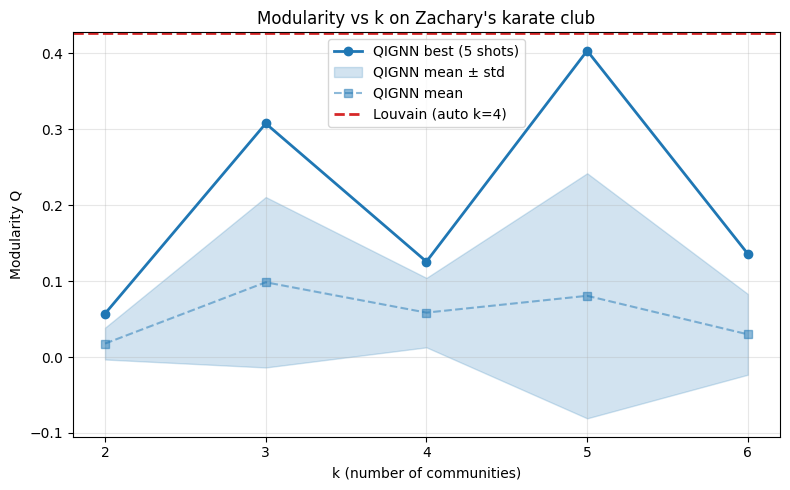


QIGNN-optimal k by modularity: k* = 5 (mod = 0.4036, used 2 non-empty communities)


In [8]:
ks_arr = np.array([r['k'] for r in results])
mod_best = np.array([r['mod_best'] for r in results])
mod_mean = np.array([r['mod_mean'] for r in results])
mod_std  = np.array([r['mod_std']  for r in results])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks_arr, mod_best, 'o-', color='tab:blue', label='QIGNN best (5 shots)', lw=2)
ax.fill_between(ks_arr, mod_mean - mod_std, mod_mean + mod_std,
                color='tab:blue', alpha=0.2, label='QIGNN mean ± std')
ax.plot(ks_arr, mod_mean, 's--', color='tab:blue', alpha=0.5, label='QIGNN mean')
ax.axhline(louv_mod, color='tab:red', ls='--', lw=2,
           label=f'Louvain (auto k={len(louv_comms)})')
ax.set_xlabel('k (number of communities)')
ax.set_ylabel('Modularity Q')
ax.set_title("Modularity vs k on Zachary's karate club")
ax.set_xticks(ks_arr)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

best_k_row = max(results, key=lambda r: r['mod_best'])
print(f"\nQIGNN-optimal k by modularity: k* = {best_k_row['k']} "
      f"(mod = {best_k_row['mod_best']:.4f}, "
      f"used {best_k_row['n_comms_used_best']} non-empty communities)")